# MoCap Analysis — Transform to TFrame Coordinate System

**Workflow:**
- `multiple_rigid_body.py` is loaded once via `importlib`.
- It runs its `__main__` block which produces `rb_dfs` and `st_time`.
- This notebook uses those DataFrames directly — no CSV re-read.

**Pipeline:**
1. Imports
2. Load script → get `rb_dfs` and `st_time`
3. Verify DataFrames are ready
4. Inspect raw data
5. Define and run coordinate frame transform
6. Sanity checks
7. Print noark m2 position in tframe (metres)
8. Print table m1–m6 positions in tframe (metres)


## Cell 1 — Imports

In [17]:
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

print('Libraries loaded OK')

Libraries loaded OK


## Cell 2 — Load `multiple_rigid_body.py`

Walks up from the notebook directory to find the repo root,
then loads the script via `importlib`. The script's `__main__` block
runs automatically and populates `rb_dfs` and `st_time` into this
notebook's namespace.

In [ ]:
# ── locate notebook & repo root ───────────────────────────────────────────────
try:
    _nb_file = Path(globals()['__vsc_ipynb_file__']).resolve()
    _nb_dir  = _nb_file.parent
except KeyError:
    _nb_dir = Path.cwd()

repo_root = _nb_dir
for candidate in [_nb_dir, *_nb_dir.parents]:
    if (candidate / 'vaideesh').exists() or (candidate / '.venv').exists():
        repo_root = candidate
        break

print(f'Repo root : {repo_root}')

# ── load multiple_rigid_body module ───────────────────────────────────────────
_script_path = repo_root / 'vaideesh' / 'Analysis' / 'multiple_rigid_body.py'
assert _script_path.exists(), f'Script not found: {_script_path}'

_script_dir = str(_script_path.parent)
if _script_dir not in sys.path:
    sys.path.insert(0, _script_dir)

spec = importlib.util.spec_from_file_location('multiple_rigid_body', _script_path)
mrb  = importlib.util.module_from_spec(spec)
sys.modules['multiple_rigid_body'] = mrb
spec.loader.exec_module(mrb)

# ── bring helper functions into notebook namespace ────────────────────────────
add_datetime_col_3rb   = mrb.add_datetime_col_3rb
trunkate_3_dfs         = mrb.trunkate_3_dfs
trunkate_dfs           = mrb.trunkate_dfs
get_rb_pos_cols        = mrb.get_rb_pos_cols
get_rb_rot_cols        = mrb.get_rb_rot_cols
get_rb_marker_name_3rb = mrb.get_rb_marker_name_3rb


# ══════════════════════════════════════════════════════════════════════════════
# load_csv_auto  —  auto-detects rigid bodies and calls read_3_rigid_body_csv
#
# read_3_rigid_body_csv already accepts 2 or 3 rb_names so there is no
# separate read_2_rigid_body_csv — one function handles both cases.
# trunkate_3_dfs requires exactly 3 DFs; for 2-body files we use trunkate_dfs.
# ══════════════════════════════════════════════════════════════════════════════
def load_csv_auto(csv_path, mrb, truncate=True):
    """
    1. Scan the Motive CSV header to detect rigid body names (any count).
    2. Call mrb.read_3_rigid_body_csv — it accepts 2 or 3 rb_names.
    3. Add datetime column to every body.
    4. Truncate all bodies to their shared time window.
    5. Return (rb_dfs, st_time, detected_names).

    Raises a clear error if fewer than 2 or more than 3 bodies are found,
    since read_3_rigid_body_csv only supports 2–3.
    """
    csv_path = str(csv_path)

    # ── Step 1: detect rigid body names in file order ─────────────────────────
    _raw      = pd.read_csv(csv_path, skiprows=2, header=None, dtype=str)
    _type_row = _raw.iloc[0].fillna('').str.strip().tolist()
    _name_row = _raw.iloc[1].fillna('').str.strip().tolist()

    detected = []
    for t, n in zip(_type_row, _name_row):
        if t == 'Rigid Body' and n and n not in detected:
            detected.append(n)

    n = len(detected)
    print(f'  Detected {n} rigid bod{"y" if n == 1 else "ies"}: {detected}')

    if n not in (2, 3):
        raise ValueError(
            f'load_csv_auto: found {n} rigid bodies {detected} in\n  {csv_path}\n'
            f'read_3_rigid_body_csv supports 2 or 3 bodies only.'
        )

    # ── Step 2: read using the detected names ─────────────────────────────────
    rb_dfs, st_time = mrb.read_3_rigid_body_csv(csv_path, rb_names=detected)

    # ── Step 3: add absolute datetime to every body ───────────────────────────
    rb_dfs = mrb.add_datetime_col_3rb(rb_dfs, st_time)

    # ── Step 4: truncate to shared time window ────────────────────────────────
    if truncate:
        names = list(rb_dfs.keys())
        if n == 3:
            # trunkate_3_dfs requires exactly 3 positional DataFrames
            rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]] = mrb.trunkate_3_dfs(
                rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]],
                display_print=True,
            )
        else:  # n == 2  — trunkate_dfs handles exactly 2
            rb_dfs[names[0]], rb_dfs[names[1]] = mrb.trunkate_dfs(
                rb_dfs[names[0]], rb_dfs[names[1]],
                display_print=True,
            )

    return rb_dfs, st_time, detected


# ── File paths — only these two lines need changing per experiment ─────────────
TABLE_FILE = mrb.FILE
NOARK_FILE = "E:\\Ragav\\MS Bio Engineering\\NOARK_backbone\\mocap_data_t1\\linear_t2.csv"

# ── Step 1: Load table_frame CSV ──────────────────────────────────────────────
print(f'Loading TABLE file: {TABLE_FILE}')
table_rb_dfs, st_time, table_bodies = load_csv_auto(TABLE_FILE, mrb)

# tframe and table must be present — fail early with a clear message if not
for required in ('tframe', 'table'):
    assert required in table_rb_dfs, (
        f'"{required}" not found in TABLE file. '
        f'Detected bodies were: {table_bodies}. '
        f'Check Motive body names match exactly.'
    )

# ── Step 2: Load experiment/noark CSV ────────────────────────────────────────
print(f'\nLoading NOARK file: {NOARK_FILE}')
noark_rb_dfs, noark_st_time, noark_bodies = load_csv_auto(NOARK_FILE, mrb)

# ── Step 3: Merge — tframe + table always from the table file ─────────────────
# If the noark CSV happens to also contain 'tframe' or 'table' bodies they are
# intentionally skipped so the table-frame definition is never overwritten.
rb_dfs  = {
    'tframe': table_rb_dfs['tframe'],
    'table' : table_rb_dfs['table'],
}
skipped = []
for k, v in noark_rb_dfs.items():
    if k in ('tframe', 'table'):
        skipped.append(k)
    else:
        rb_dfs[k] = v

if skipped:
    print(f'  Note: {skipped} also present in NOARK file — kept table-file version (correct).')

print(f'\nCombined rb_dfs keys : {list(rb_dfs.keys())}')
print(f'Script loaded        : {_script_path}')
print(f'Capture start time   : {st_time}')


Repo root : E:\Ragav\MS Bio Engineering\NOARK_backbone
Loading TABLE file: E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_data_t1\table_frame_t2.csv
  Detected 2 rigid bodies: ['table', 'tframe']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 125

Loading NOARK file: E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_data_t1\linear_t2.csv
  Detected 2 rigid bodies: ['noark', 'table']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 1447
  Note: ['table'] also present in NOARK file — kept table-file version (correct).

Combined rb_dfs keys : ['tframe', 'table', 'noark']
Script loaded        : E:\Ragav\MS Bio Engineering\NOARK_backbone\vaideesh\Analysis\multiple_rigid_body.py
Capture start time   : 2026-04-23 11:30:45.665000


## Cell 3 — Verify DataFrames

The `__main__` block in `multiple_rigid_body.py` already calls
`add_datetime_col_3rb()` and `trunkate_3_dfs()`, so the DataFrames
are ready to use as-is. This cell just confirms their shapes and
that a `time` column is present.

In [19]:
print('DataFrames from multiple_rigid_body.py:')
print(f'{"Body":<10}  {"Shape":<15}  {"Has time col"}')
print('-' * 40)
for name, df in rb_dfs.items():
    has_time = 'time' in df.columns
    print(f'{name:<10}  {str(df.shape):<15}  {has_time}')

print('\nNaN rows per body:')
for name, df in rb_dfs.items():
    nan_rows = df.isna().any(axis=1).sum()
    print(f'  {name}: {nan_rows} NaN rows out of {len(df)}')

DataFrames from multiple_rigid_body.py:
Body        Shape            Has time col
----------------------------------------
tframe      (126, 27)        True
table       (126, 35)        True
noark       (1448, 27)       True

NaN rows per body:
  tframe: 1 NaN rows out of 126
  table: 1 NaN rows out of 126
  noark: 1 NaN rows out of 1448


## Cell 4 — Inspect raw DataFrames

In [ ]:
print('── tframe ──')
display(rb_dfs['tframe'].head(3))

In [ ]:
noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
print(f'── {noark_key} ──')
display(rb_dfs[noark_key].head(3))

In [ ]:
print('── table ──')
display(rb_dfs['table'].head(3))

## Cell 5 — Define `transform_to_tframe()`

**Coordinate frame construction (per frame, from mocap marker positions):**

| Step | Detail |
|---|---|
| Origin | `tframe_marker_1` position in mocap frame |
| X axis | `tframe_marker_3 − origin`, normalised |
| Y axis | `tframe_marker_2 − origin`, Gram-Schmidt orthogonalised then normalised |
| Z axis | `X × Y` (right-handed) |
| Translation reference | `tframe_marker_1` → becomes **(0, 0, 0)** in table frame |

**Transform formula:** `p_table = R_mocap2table.T @ (p_mocap − t_mocap)`  
where `R_mocap2table` columns are `[vxnorm, vynorm, vznorm]` and `t_mocap = tvec(tframe_marker_3)`.

**Units:** Motive exports positions in **metres** — no conversion needed.  
**Column suffix `_m`** makes the unit explicit in every position column.


In [20]:
def transform_to_tframe(rb_dfs):
    tframe_df = rb_dfs['tframe'].copy()
    noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
    noark_df  = rb_dfs[noark_key].copy()
    print(f'Using noark key: "{noark_key}"')
    table_df  = rb_dfs['table'].copy()

    # ── Build a SINGLE fixed coordinate frame from mean tframe marker positions ──
    m1 = tframe_df[['tframe_marker_m1_x', 'tframe_marker_m1_y', 'tframe_marker_m1_z']].mean().values.astype(float)
    m2 = tframe_df[['tframe_marker_m2_x', 'tframe_marker_m2_y', 'tframe_marker_m2_z']].mean().values.astype(float)
    m3 = tframe_df[['tframe_marker_m4_x', 'tframe_marker_m4_y', 'tframe_marker_m4_z']].mean().values.astype(float)

    # Origin = m1, X = m2 - m1, Y = m3 - m1
    org = m1
    v1  = m2 - org # X-axis coordinate
    v2  = m3 - org  # Y-axis coordinate

    # Gram-Schmidt orthonormalisation → single fixed rotation matrix
    vxnorm = v1 / np.linalg.norm(v1)
    vycap  = v2 - np.dot(v2, vxnorm) * vxnorm
    vynorm = vycap / np.linalg.norm(vycap)
    vznorm = np.cross(vxnorm, vynorm)

    R_mat  = np.stack([vxnorm, vynorm, vznorm], axis=-1)  # (3, 3) — fixed
    t_vec  = m1                                            # fixed origin in mocap frame

    # ── Helper: transform any (N,3) array into table frame ───────────────────
    def pos_to_tframe(p_mocap):
        return (R_mat.T @ (p_mocap - t_vec).T).T          # (N, 3)

    # ── noark ─────────────────────────────────────────────────────────────────
    noark_result = pd.DataFrame({
        'frame'  : noark_df['frame'].values,
        'seconds': noark_df['seconds'].values,
        'time'   : noark_df['time'].values,
    })

    for col_suffix, out_suffix in [('m2', 'noark_m2'), ('m5', 'noark_m5')]:
        try:
            p = noark_df[[f'{noark_key}_marker_{col_suffix}_x',
                f'{noark_key}_marker_{col_suffix}_y',
                f'{noark_key}_marker_{col_suffix}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            noark_result[f'{out_suffix}_tf_x_m'] = p_tf[:, 0]
            noark_result[f'{out_suffix}_tf_y_m'] = p_tf[:, 1]
            noark_result[f'{out_suffix}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            print(f'  skipping {col_suffix} — not found in noark columns')

    # ── table ─────────────────────────────────────────────────────────────────
    table_result = pd.DataFrame({
        'frame'  : table_df['frame'].values,
        'seconds': table_df['seconds'].values,
        'time'   : table_df['time'].values,
    })

    for i in range(1, 7):
        try:
            p = table_df[[f'table_marker_m{i}_x',
                           f'table_marker_m{i}_y',
                           f'table_marker_m{i}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            table_result[f'table_m{i}_tf_x_m'] = p_tf[:, 0]
            table_result[f'table_m{i}_tf_y_m'] = p_tf[:, 1]
            table_result[f'table_m{i}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            pass

    return {
        'noark_in_tframe' : noark_result.reset_index(drop=True),
        'table_in_tframe' : table_result.reset_index(drop=True),
        '_R_mat'          : R_mat,
        '_t_vec'          : t_vec,
        '_tframe_m3_mocap': m3,
    }

## Cell 6 — Run the transformation

In [21]:
tframe_dfs = transform_to_tframe(rb_dfs)

print('noark_in_tframe shape :', tframe_dfs['noark_in_tframe'].shape)
print('table_in_tframe shape :', tframe_dfs['table_in_tframe'].shape)
print('\nnoark_in_tframe columns:')
print(tframe_dfs['noark_in_tframe'].columns.tolist())
print('\ntable_in_tframe columns:')
print(tframe_dfs['table_in_tframe'].columns.tolist())

Using noark key: "noark"
  skipping m5 — not found in noark columns
noark_in_tframe shape : (1448, 6)
table_in_tframe shape : (126, 21)

noark_in_tframe columns:
['frame', 'seconds', 'time', 'noark_m2_tf_x_m', 'noark_m2_tf_y_m', 'noark_m2_tf_z_m']

table_in_tframe columns:
['frame', 'seconds', 'time', 'table_m1_tf_x_m', 'table_m1_tf_y_m', 'table_m1_tf_z_m', 'table_m2_tf_x_m', 'table_m2_tf_y_m', 'table_m2_tf_z_m', 'table_m3_tf_x_m', 'table_m3_tf_y_m', 'table_m3_tf_z_m', 'table_m4_tf_x_m', 'table_m4_tf_y_m', 'table_m4_tf_z_m', 'table_m5_tf_x_m', 'table_m5_tf_y_m', 'table_m5_tf_z_m', 'table_m6_tf_x_m', 'table_m6_tf_y_m', 'table_m6_tf_z_m']


## Cell 7 — Inspect transformed DataFrames

In [ ]:
print('── noark in tframe ──')
display(tframe_dfs['noark_in_tframe'].head())

In [ ]:
print('── table in tframe ──')
display(tframe_dfs['table_in_tframe'].head())

## Cell 8 — Sanity checks

In [22]:
# ── Sanity checks — fixed (3,3) rotation matrix ──────────────────────────────
R_mat = tframe_dfs['_R_mat']           # (3,3)
t_vec = tframe_dfs['_t_vec']           # (3,) — tframe_marker_1 = origin

def _chk(label, val, tol, unit=''):
    print(f'  {label:<46} {val:.2e} {unit}  →  {"PASS ✓" if val < tol else "FAIL ✗"}')

print('Sanity checks')
print('─' * 62)

# Check 1: origin (t_vec = m1) maps to (0,0,0)
p_origin = R_mat.T @ (t_vec - t_vec)
_chk('Check 1  origin (tframe_m1) → (0,0,0)', np.max(np.abs(p_origin)), 1e-10, 'm')

# Check 2: R columns are unit vectors
col_norms = np.linalg.norm(R_mat, axis=0)
_chk('Check 2  R columns are unit vectors', np.max(np.abs(col_norms - 1.0)), 1e-6)

# Check 3: R.T @ R = I
RtR = R_mat.T @ R_mat
_chk('Check 3  R.T @ R = I  (orthogonality)', np.max(np.abs(RtR - np.eye(3))), 1e-6)

# Check 4: det(R) = +1
det = np.linalg.det(R_mat)
print(f'  {"Check 4  det(R) = +1  (right-handed)":<46} det = {det:.8f}  →  {"PASS ✓" if abs(det-1.0)<1e-6 else "FAIL ✗"}')

print(f'\nR_mat (columns = X/Y/Z axes of table frame in mocap):\n{np.round(R_mat, 6)}')
print(f'\nt_vec (table origin = tframe_m1 in mocap, m): {np.round(t_vec, 6)}')


Sanity checks
──────────────────────────────────────────────────────────────
  Check 1  origin (tframe_m1) → (0,0,0)          0.00e+00 m  →  PASS ✓
  Check 2  R columns are unit vectors            2.22e-16   →  PASS ✓
  Check 3  R.T @ R = I  (orthogonality)          3.33e-16   →  PASS ✓
  Check 4  det(R) = +1  (right-handed)           det = 1.00000000  →  PASS ✓

R_mat (columns = X/Y/Z axes of table frame in mocap):
[[-0.996399  0.032013  0.078509]
 [ 0.028129  0.998348 -0.050095]
 [-0.079983 -0.047707 -0.995654]]

t_vec (table origin = tframe_m1 in mocap, m): [ 0.115742 -0.08178  -0.367363]


In [ ]:
# (Quaternion-norm check removed — new transform is purely positional/marker-based,
#  no quaternion output is produced. Add orientation output here if needed later.)
print('No quaternion output in this transform — skipping norm check.')


## Cell 9 — noark m2 position in tframe (metres)

In [23]:
# Cell 9 — noark m2
df_n = tframe_dfs['noark_in_tframe']
print('noark Marker 2 — position in tframe coordinate system (metres)')
print(df_n[['frame','seconds','noark_m2_tf_x_m','noark_m2_tf_y_m','noark_m2_tf_z_m']].to_string(index=False))
print('\nSummary statistics (metres):')
display(df_n[['noark_m2_tf_x_m','noark_m2_tf_y_m','noark_m2_tf_z_m']].describe().round(6))

noark Marker 2 — position in tframe coordinate system (metres)
 frame  seconds  noark_m2_tf_x_m  noark_m2_tf_y_m  noark_m2_tf_z_m
     0     0.00        -0.267934         0.196630        -0.172542
     1     0.01        -0.267928         0.196658        -0.172530
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.267931         0.196658        -0.172528
     4     0.04        -0.267925         0.196636        -0.172524
     5     0.05        -0.267922         0.196670        -0.172527
     6     0.06        -0.267925         0.196658        -0.172532
     7     0.07        -0.267913         0.196645        -0.172536
     8     0.08        -0.267928         0.196647        -0.172538
     9     0.09        -0.267929         0.196661        -0.172543
    10     0.10        -0.267918         0.196665        -0.172544
    11     0.11        -0.267922         0.196668        -0.172545
    12     0.12        -0.267925         0.196657        -0.172545

,noark_m2_tf_x_m,noark_m2_tf_y_m,noark_m2_tf_z_m
count,1447.000000,1447.000000,1447.000000
mean,-0.117882,0.190716,-0.271075
std,0.185233,0.004641,0.079654
min,-0.270082,0.181847,-0.384411
25%,-0.266248,0.186979,-0.368634
50%,-0.248951,0.190875,-0.214600
75%,0.004888,0.195072,-0.207785
max,0.236271,0.196975,-0.172524


## Cell 10 — Table marker m1–m6 positions in tframe (metres)


In [ ]:
# Cell 10 — table m1–m6
df_t = tframe_dfs['table_in_tframe']
for i in range(1, 7):
    cols = [f'table_m{i}_tf_x_m', f'table_m{i}_tf_y_m', f'table_m{i}_tf_z_m']
    print(f'\ntable Marker {i} — position in tframe coordinate system (metres)')
    print(df_t[['frame','seconds'] + cols].to_string(index=False))
    print(f'\nSummary statistics — Marker {i} (metres):')
    display(df_t[cols].describe().round(6))

## Cell 10b — Diagnostic: actual XY positions of all table markers

Print mean X/Y of every table marker so we can verify the correct label mapping.


Mean positions of all table markers in table frame (cm)
  Marker            X (cm)      Y (cm)      Z (cm)
--------------------------------------------------
  table_m1              47.97        3.86      -77.15
  table_m2             -50.64        4.77      -75.51
  table_m3              -8.45        8.47      -68.95
  table_m4              48.95        6.81       -2.70
  table_m5               4.53        8.32      -69.07
  table_m6             -49.34        8.04       -1.11


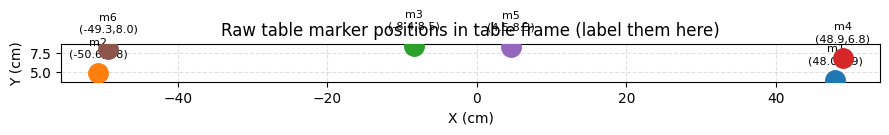


Use this plot to confirm which m# corresponds to P1/P2/P3/P4/M1/M2


In [24]:
import matplotlib.pyplot as plt
import numpy as np

df_t = tframe_dfs['table_in_tframe'].copy()

print('Mean positions of all table markers in table frame (cm)')
print(f'  {"Marker":<12}  {"X (cm)":>10}  {"Y (cm)":>10}  {"Z (cm)":>10}')
print('-' * 50)
marker_xy = {}
for mid in range(1, 7):
    xc = f'table_m{mid}_tf_x_m'
    yc = f'table_m{mid}_tf_y_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns:
        x = df_t[xc].mean() * 100
        y = df_t[yc].mean() * 100
        z = df_t[zc].mean() * 100
        marker_xy[mid] = (x, y)
        print(f'  table_m{mid:<6}    {x:>10.2f}  {y:>10.2f}  {z:>10.2f}')
    else:
        print(f'  table_m{mid:<6}    NOT FOUND')

# ── Quick scatter so spatial layout is immediately visible ────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for mid, (x, y) in marker_xy.items():
    ax.plot(x, y, marker='o', ms=14, zorder=3)
    ax.annotate(f'm{mid}\n({x:.1f},{y:.1f})', (x, y),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8)

ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
ax.set_title('Raw table marker positions in table frame (label them here)')
ax.set_aspect('equal'); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()
print('\nUse this plot to confirm which m# corresponds to P1/P2/P3/P4/M1/M2')


## Cell 12 — NOARK Marker 2: X and Z Position Over Time

Plots X and Z position of  in the table coordinate frame over time.

- **Top subplot**: X position (left ↔ right) over time
- **Bottom subplot**: Z position (up ↕ down) over time
- Axes in **cm** for readability.


Plotting NOARK marker: m2


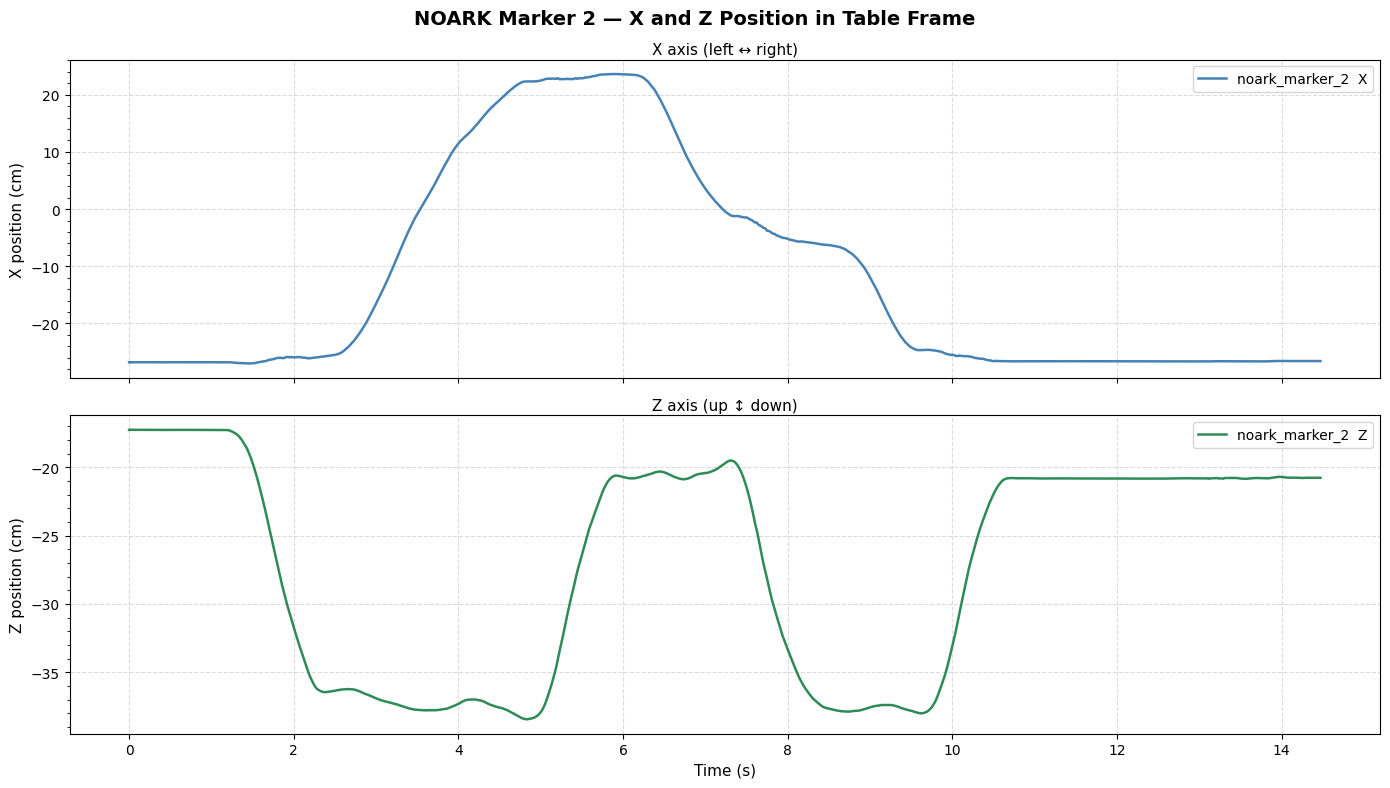

X range: nan → nan cm  (span nan cm)
Z range: nan → nan cm  (span nan cm)
Duration: 14.47 s  (1448 frames)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()

# ── Use noark_marker_2 specifically ──────────────────────────────────────────
PLOT_MARKER = 'm2'
assert f'noark_{PLOT_MARKER}_tf_x_m' in df_n.columns, (
    f'noark_{PLOT_MARKER}_tf_x_m not found. Available: {df_n.columns.tolist()}'
)
print(f'Plotting NOARK marker: {PLOT_MARKER}')

cam_t = df_n['seconds'].values
cam_x = df_n[f'noark_{PLOT_MARKER}_tf_x_m'].values * 100.0   # m → cm
cam_z = df_n[f'noark_{PLOT_MARKER}_tf_z_m'].values * 100.0   # m → cm

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('NOARK Marker 2 — X and Z Position in Table Frame',
             fontsize=14, fontweight='bold')

# ── X subplot ─────────────────────────────────────────────────────────────────
ax1.plot(cam_t, cam_x, color='steelblue', lw=1.8, label='noark_marker_2  X')
ax1.set_ylabel('X position (cm)', fontsize=11)
ax1.set_title('X axis (left ↔ right)', fontsize=11, pad=4)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.45)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.tick_params(axis='both', labelsize=10)

# annotate min/max
_xi = np.argmin(cam_x); _xa = np.argmax(cam_x)
ax1.annotate(f'min {cam_x[_xi]:.1f} cm', xy=(cam_t[_xi], cam_x[_xi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')
ax1.annotate(f'max {cam_x[_xa]:.1f} cm', xy=(cam_t[_xa], cam_x[_xa]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')

# ── Z subplot ─────────────────────────────────────────────────────────────────
ax2.plot(cam_t, cam_z, color='seagreen', lw=1.8, label='noark_marker_2  Z')
ax2.set_ylabel('Z position (cm)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_title('Z axis (up ↕ down)', fontsize=11, pad=4)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.45)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.tick_params(axis='both', labelsize=10)

# annotate min/max
_zi = np.argmin(cam_z); _za = np.argmax(cam_z)
ax2.annotate(f'min {cam_z[_zi]:.1f} cm', xy=(cam_t[_zi], cam_z[_zi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')
ax2.annotate(f'max {cam_z[_za]:.1f} cm', xy=(cam_t[_za], cam_z[_za]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')

plt.tight_layout()
plt.savefig('Mocap_NOARK_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range: {cam_x.min():.2f} → {cam_x.max():.2f} cm  (span {cam_x.max()-cam_x.min():.2f} cm)')
print(f'Z range: {cam_z.min():.2f} → {cam_z.max():.2f} cm  (span {cam_z.max()-cam_z.min():.2f} cm)')
print(f'Duration: {cam_t[-1] - cam_t[0]:.2f} s  ({len(cam_t)} frames)')


## Cell 14 — 2D Trajectory of NOARK Marker 2 (X–Z Table Frame)

Scatter plot of  X and Z position in the table coordinate frame.
- **Colour** encodes time progression (early → late).
- **▲ triangles** mark pulley reference points P1–P4 from table markers.
- Axes in **cm**.


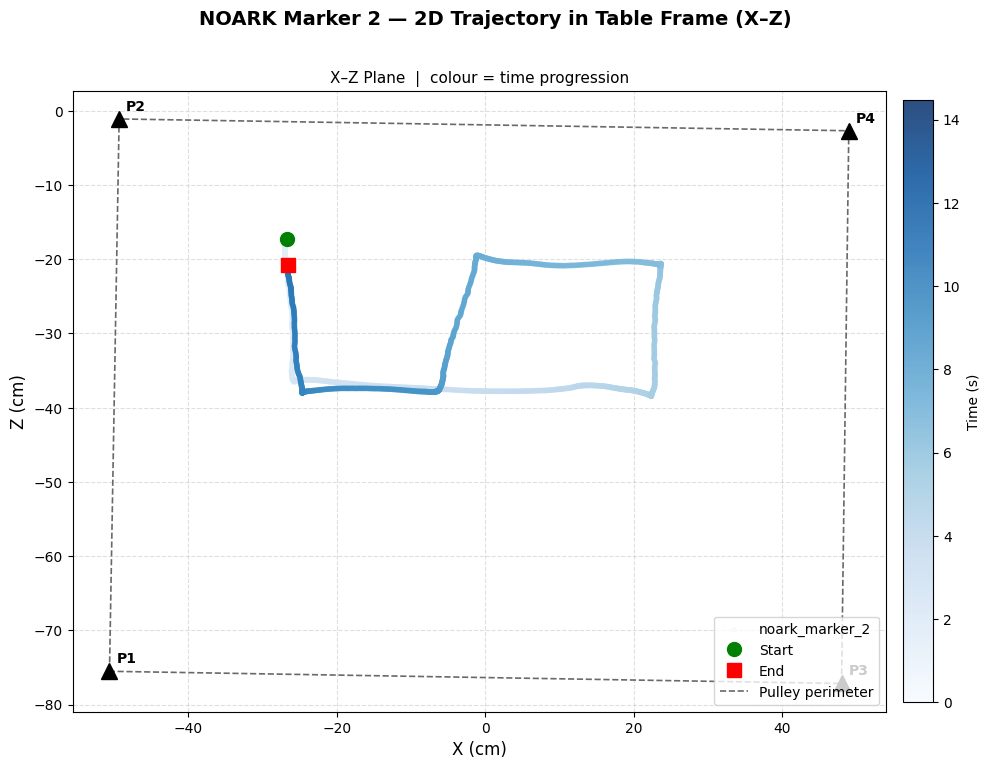

X range : nan → nan cm
Z range : nan → nan cm
Frames  : 1448  |  Duration: 14.47 s


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()

# ── noark_marker_2 X and Z in cm ─────────────────────────────────────────────
x_cam_cm = df_n['noark_m2_tf_x_m'].values * 100.0
z_cam_cm = df_n['noark_m2_tf_z_m'].values * 100.0
t_sec    = df_n['seconds'].values

# ── Pulley reference points (mean positions) ──────────────────────────────────
# table_Marker2=P1, table_Marker6=P2, table_Marker1=P3, table_Marker4=P4
PULLEY_MAP = {'P1': 2, 'P2': 6, 'P3': 1, 'P4': 4}
pulley_pos = {}
for label, mid in PULLEY_MAP.items():
    xc = f'table_m{mid}_tf_x_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns and zc in df_t.columns:
        pulley_pos[label] = (
            df_t[xc].mean() * 100.0,
            df_t[zc].mean() * 100.0,
        )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('MOCAP_NOARK — 2D Trajectory in Table Frame (X–Z)',
             fontsize=14, fontweight='bold')

# Trajectory scatter coloured by time
sc = ax.scatter(
    x_cam_cm, z_cam_cm,
    c=t_sec, cmap='Blues',
    s=10, alpha=0.85,
    label='noark_marker_2',
    zorder=3,
)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label('Time (s)', fontsize=10)

# Start and end markers
ax.plot(x_cam_cm[0],  z_cam_cm[0],  'go', ms=10, zorder=5, label='Start')
ax.plot(x_cam_cm[-1], z_cam_cm[-1], 'rs', ms=10, zorder=5, label='End')

# Pulley reference points
for lbl, (px, pz) in pulley_pos.items():
    ax.plot(px, pz, 'k^', ms=11, zorder=4)
    ax.annotate(lbl, (px, pz),
                xytext=(5, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

# Pulley perimeter outline
porder = ['P1', 'P2', 'P4', 'P3']
pcoords = [pulley_pos[p] for p in porder if p in pulley_pos]
if len(pcoords) == 4:
    pcoords_closed = pcoords + [pcoords[0]]
    ax.plot([p[0] for p in pcoords_closed],
            [p[1] for p in pcoords_closed],
            color='dimgray', lw=1.2, ls='--', zorder=2, label='Pulley perimeter')

ax.set_xlabel('X (cm)', fontsize=12)
ax.set_ylabel('Z (cm)', fontsize=12)
ax.set_title('X–Z Plane  |  colour = time progression', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('noark_m2_xz_trajectory_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range : {x_cam_cm.min():.2f} → {x_cam_cm.max():.2f} cm')
print(f'Z range : {z_cam_cm.min():.2f} → {z_cam_cm.max():.2f} cm')
print(f'Frames  : {len(t_sec)}  |  Duration: {t_sec[-1]-t_sec[0]:.2f} s')


## Cell 13 — Pulley-to-Pulley Distances

Computes Euclidean distances between the four pulley markers in the table frame.

| Pair | Markers | Physical meaning |
|---|---|---|
| P1–P2 | m2 – m6 | Left side |
| P1–P3 | m2 – m1 | Diagonal |
| P3–P4 | m1 – m4 | Right side |
| P2–P4 | m6 – m4 | Diagonal |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_t = tframe_dfs['table_in_tframe'].copy()

# ── Marker → label mapping ────────────────────────────────────────────────────
# table_Marker1=m1=P3, table_Marker2=m2=P1, table_Marker4=m4=P4, table_Marker6=m6=P2
MARKER_MAP  = {1:('P3','black','^'), 2:('P1','black','^'),
               3:('M1','steelblue','s'), 4:('P4','black','^'),
               5:('M2','steelblue','s'), 6:('P2','black','^')}
pulley_ids  = {'P1':2, 'P2':6, 'P3':1, 'P4':4}

# ── Mean positions (metres) ───────────────────────────────────────────────────
def get_mean_pos(mid):
    cols = [f'table_m{mid}_tf_{ax}_m' for ax in ('x','y','z')]
    missing = [c for c in cols if c not in df_t.columns]
    if missing:
        raise KeyError(f'Columns missing for table marker {mid}: {missing}')
    return df_t[cols].mean().values   # (3,) metres

pos = {lbl: get_mean_pos(mid) for lbl, mid in pulley_ids.items()}

# ── Distance pairs ────────────────────────────────────────────────────────────
pairs = [('P1','P2'), ('P1','P3'), ('P3','P4'), ('P2','P4')]

print('Pulley-to-Pulley Distances in Table Frame')
print('=' * 50)
print(f'  {"Pair":<10}  {"Distance (cm)":>14}  {"Distance (m)":>13}')
print('-' * 50)
distances = {}
for a, b in pairs:
    d_m  = np.linalg.norm(pos[a] - pos[b])
    d_cm = d_m * 100.0
    distances[(a, b)] = d_cm
    print(f'  {a}-{b:<7}  {d_cm:>14.3f}  {d_m:>13.6f}')
print('-' * 50)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

# all table markers
marker_xy = {}
for mid in range(1, 7):
    xc, yc = f'table_m{mid}_tf_x_m', f'table_m{mid}_tf_y_m'
    if xc not in df_t.columns:
        continue
    x = df_t[xc].mean() * 100
    y = df_t[yc].mean() * 100
    marker_xy[mid] = (x, y)
    lbl, clr, shp = MARKER_MAP[mid]
    ax.plot(x, y, marker=shp, ms=13, color=clr, zorder=4)
    ax.annotate(lbl, (x, y), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color=clr)

# distance lines with annotated values
pair_mid   = {'P1':2, 'P2':6, 'P3':1, 'P4':4}
pair_colors = ['royalblue', 'darkorange', 'seagreen', 'crimson']
for (a, b), color in zip(pairs, pair_colors):
    ma, mb = pair_mid[a], pair_mid[b]
    if ma not in marker_xy or mb not in marker_xy:
        continue
    x0, y0 = marker_xy[ma]
    x1, y1 = marker_xy[mb]
    ax.plot([x0, x1], [y0, y1], color=color, lw=1.8, zorder=2)
    label_text = a + '-' + b + '\n' + f'{distances[(a,b)]:.1f} cm'
    ax.annotate(label_text, ((x0+x1)/2, (y0+y1)/2),
                fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.85))

# pulley perimeter
pxy = [marker_xy[m] for m in [2, 6, 4, 1] if m in marker_xy]
if len(pxy) == 4:
    xs = [p[0] for p in pxy] + [pxy[0][0]]
    ys = [p[1] for p in pxy] + [pxy[0][1]]
    ax.plot(xs, ys, color='dimgray', lw=1, ls='--', zorder=1)

ax.set_xlabel('X (cm)', fontsize=11)
ax.set_ylabel('Y (cm)', fontsize=11)
ax.set_title('Pulley Layout and Distances in Table Frame', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()
